<a href="https://colab.research.google.com/github/andiunsia/DataScience_240401010009_Andi/blob/main/Pertemuan5_Andi_240401010009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
Nama : Andi

NIM : 240401010009

Kelas : IF401

---

# **Latihan Pertemuan 5**

# **Visualisasi Statis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 1. LOAD & INSPECT DATASET

In [ ]:
df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print(df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


# 2. GRAPH

/tmp/ipykernel_416/4081679598.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


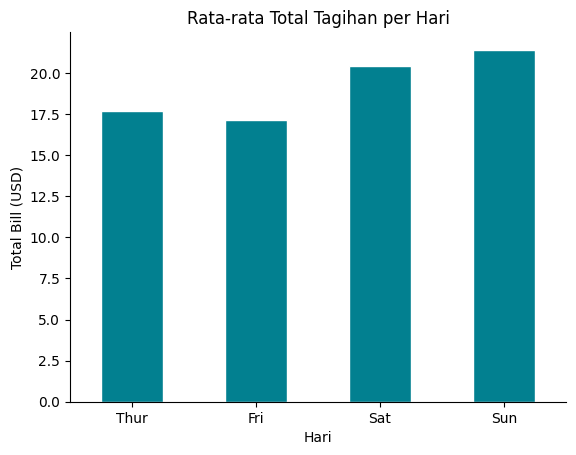

In [ ]:
#3. GRAFIK 1: Bar Chart**

avg_by_day = df.groupby('day')['total_bill'].mean()
ax1 = avg_by_day.plot(kind='bar', color='#028090',
                edgecolor='white')

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)


**What?**
Grafik bar menunjukkan rata-rata harian total tagihan pelanggan restoran. Rata-rata total tagihan tertinggi sekitar 21 USD pada hari minggu, sedangkan rata-rata paling rendah sekitar 17 USD pada hari jumat.

**So what?**
Pada akhir pekan pelanggan cenderung memesan makanan lebih banyak dibandingkan hari kerja. Kemungkinan aktivitas akhir pekan diisi dengan kumpul bersama keluarga atau rekan-rekan, salah satunya dengan makan bersama.

**Now what?**
Setiap akhir pekan Restoran harus mengantisipasi peningkatan pelanggan yaitu dengan menambah bahan makanan dan jumlah staff yang akan melayani pelanggan.

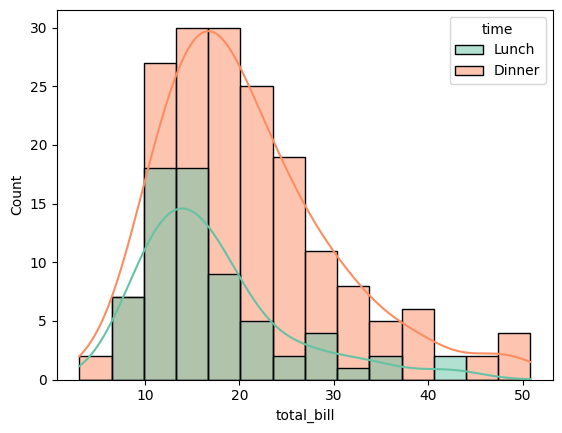

In [ ]:
#4. GRAFIK 2: Histogram + KDE

sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2')

ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)


**What?** Histogram dengan KDE menunjukkan distribusi total tagihan pelanggan. Total tagilan berada pada rentang 3 ~ 50 USD dengan distribusi terbanyak berada pada rentang 10 ~ 25 USD pada makan malam.

**So what?** Restotan lebih ramai pada saat makan malam dibandingkan saat makan siang. Pekerja yang sudah capek sepulang bekerja cenderung lebih memilih untuk makan malam di restoran.

**Now what?** Restoran harus mengkondisikan staffnya agar lebih siap saat waktu makan malam.

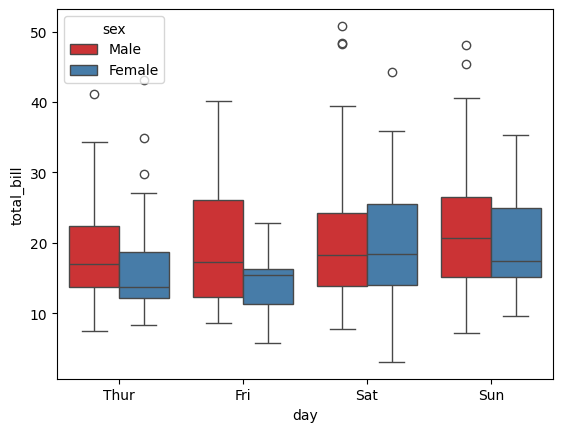

In [ ]:
#5. GRAFIK 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set1')

ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)


**What?** Boxplot menunjukkan perbandingan jenis kelamin pelanggan secara harian. Pelanggan wanita memiliki jumlah tagihan yang stabil dan lebih tinggi dari laki-laki, kecuali pada hari sabtu.

**So what?** Pada hari sabtu tagihan pelnggan laki-laki lebih banyak dibandingkan wanita. laki-laki akan mengajak temannya untuk makan di restoran pada hari sabtu malam minggu.

**Now what?** Restoran dapat melakukan promosi pada sabtu malam.

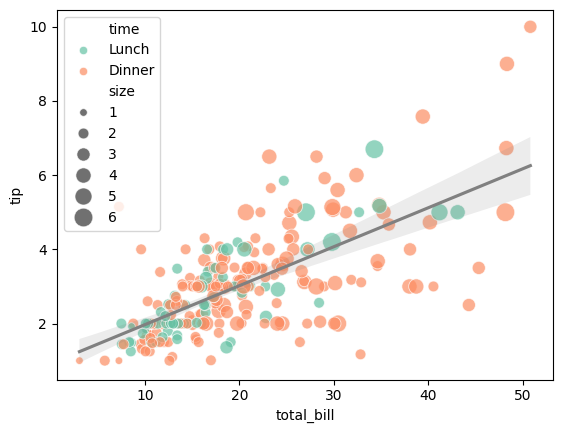

In [ ]:
#6. GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30,180),
                palette='Set2', alpha=0.7,)

sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray')

ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

**What?** Scatter plot menunjukkan hubungan positif antara total bill dan tip yang diberikan pelanggan. Secara umum semakin besar total tagihan, tip yang diberikan juga cenderung lebih besar. Ada juga beberapa pelanggan ynag memberikan tip yang tinggi walau total tagihannya kecil, dan ada juga yang sebaliknya.

**So what?** Hubungan antara total tagihan dan tip mencerminkan perilaku dan kepuasan pelanggan. Semakin besar total tagihan akan semakin besar tip yang diberikan.

**Now what?** Restoran dapat meningkatkan kualitas layanan kepada pelanggan dengan transaksi besar untuk meningkatkan kepuasan pelanggan dan peluang memperoleh tip yang lebih tinggi.

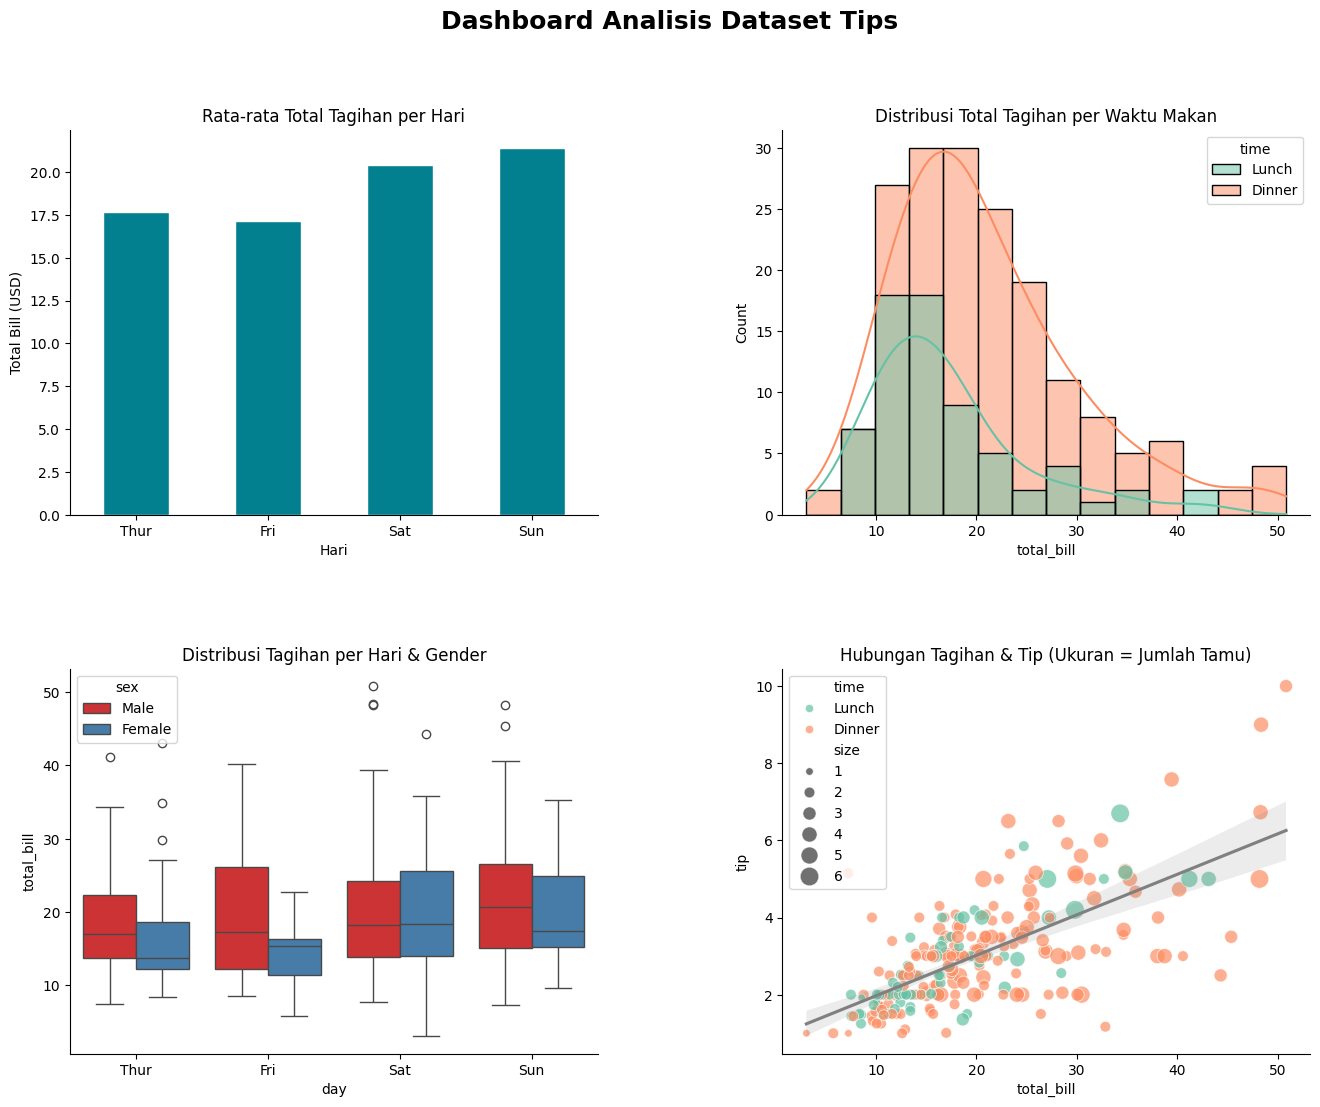

In [ ]:
# SETUP FIGURE LAYOUT
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=18, fontweight='bold', y=0.98)
# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# GRAFIK 1: Bar Chart
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# GRAFIK 2: Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# GRAFIK 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill',hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(30,180), palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

# 3. EKSPOR

In [ ]:

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

<Figure size 640x480 with 0 Axes>

Dashboard tersimpan sebagai dashboard_tips.png


# **Kesimpulan**

Eksplorasi dan visualisasi data tips dari pustaka Seaborn dengan tujuan menggali pola perilaku pelanggan restoran. Kesimpulan yang diperoleh adalah sebagai berikut:

**Pemahaman Data Awal**

Dataset berisi 244 transaksi dengan 7 variabel, data bersih tanpa nilai hilang, sehingga proses visualisasi dapat langsung dilakukan.

**Wawasan dari Visualisasi**

- Bar Chart (Rata-rata Tagihan per Hari)
- Histogram + KDE (Distribusi Tagihan per Waktu Makan)
- Boxplot (Tagihan per Hari & Gender)
- Scatter Plot (Hubungan Tagihan dan Tip)

**Implikasi Bisnis (Now What)**

Pendekatan What–So What–Now What membantu menerjemahkan grafik menjadi rekomendasi tindakan nyata.

**Dashboard Terpadu**

Keempat grafik disusun dalam satu dashboard 2×2, kemudian diekspor sebagai dashboard_tips.png untuk dokumentasi atau presentasi.